In [9]:

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [10]:
sns.set(style="whitegrid")

In [31]:
def plot_vectors(
    *vectors,
    palette="tab10",
    labels=None,
    show_coords=True,
    pad_frac=0.08,
    grid=True,
    ax=None
):
    """
    Grafica uno o varios vectores 2D desde el origen con colores de seaborn,
    flechas por annotate (fiable para color) y límites ajustados al rango útil.
    """
    if len(vectors) == 0:
        raise ValueError("Proporciona al menos un vector 2D (np.array([x, y])).")

    V = np.vstack([np.asarray(v).reshape(2) for v in vectors])

    # Tema y grilla
    sns.set_theme(style="whitegrid" if grid else "white")

    if ax is None:
        fig, ax = plt.subplots()
    else:
        fig = ax.figure

    # Paleta de colores
    colors = sns.color_palette(palette, n_colors=len(V))

    # Dibuja flechas con annotate (evita problemas de color de quiver)
    for i, (x, y) in enumerate(V):
        color = colors[i]
        ax.annotate(
            "", xy=(x, y), xytext=(0, 0),
            arrowprops=dict(arrowstyle="->", linewidth=2.5, color=color),
            zorder=3
        )
        if show_coords:
            ax.text(x*1.02, y*1.02, f"({x:g}, {y:g})", fontsize=9, color=color, zorder=4)

    # Rango que incluye el origen
    xs = np.concatenate([V[:, 0], [0.0]])
    ys = np.concatenate([V[:, 1], [0.0]])
    x_min, x_max = xs.min(), xs.max()
    y_min, y_max = ys.min(), ys.max()

    if x_min == x_max:
        x_min, x_max = x_min - 1, x_max + 1
    if y_min == y_max:
        y_min, y_max = y_min - 1, y_max + 1

    x_pad = (x_max - x_min) * pad_frac
    y_pad = (y_max - y_min) * pad_frac
    ax.set_xlim(x_min - x_pad, x_max + x_pad)
    ax.set_ylim(y_min - y_pad, y_max + y_pad)

    # Ejes cartesianos
    ax.axhline(0, color="black", linewidth=1.0, zorder=1)
    ax.axvline(0, color="black", linewidth=1.0, zorder=1)
    ax.set_aspect("equal", "box")

    # Leyenda (si se pidió)
    if labels:
        # Dibujamos handles "falsos" con el color correcto para la leyenda
        for i, lab in enumerate(labels):
            ax.plot([], [], color=colors[i], linewidth=3, label=lab)
        ax.legend(frameon=True)
    if grid:
        ax.grid(True, linestyle="--", alpha=0.6, zorder=0)

    plt.tight_layout()
    return fig, ax

## Vectores y operaciones vectoriales



### ¿Qué es un vector?
Un **vector** es una entidad matemática que tiene *magnitud* y *dirección*. En ciencia de datos lo usamos para representar observaciones o características como arreglos numéricos 🔢.

Ejemplo en 2D:  
$$\vec{v} = (v_1, v_2)$$

En general (espacio $n$-dimensional):  

$$\vec{v} = (v_1, v_2, \dots, v_n)$$


(<Figure size 640x480 with 1 Axes>, <Axes: >)

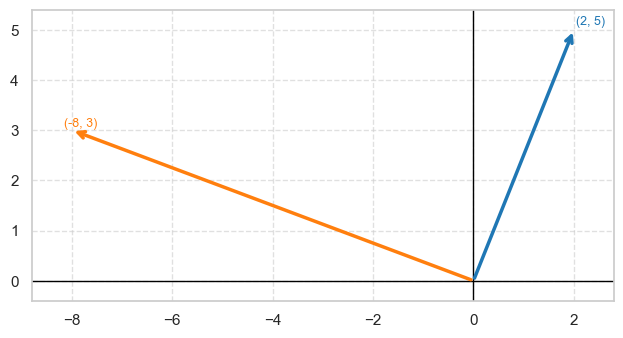

In [32]:

v = np.array([2, 5])
u = np.array([-8, 3])
v
plot_vectors(v,u)

### Operaciones con vectores
Podemos realizar operaciones como **suma**, **resta** y **producto por escalar** (multiplicar por un número real $k$).

- **Suma:** $\vec{u} + \vec{v} = (u_1+v_1,\dots,u_n+v_n)$  
- **Resta:** $\vec{u} - \vec{v} = (u_1-v_1,\dots,u_n-v_n)$  
- **Producto por escalar:** $k\vec{v} = (kv_1,\dots,kv_n)$  

In [28]:
u = np.array([1, 2])
v = np.array([4, 5])

u + v, u - v, 3 * v


(array([5, 7]), array([-3, -3]), array([12, 15]))

(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'Visualización de vectores (rango ajustado)'}>)

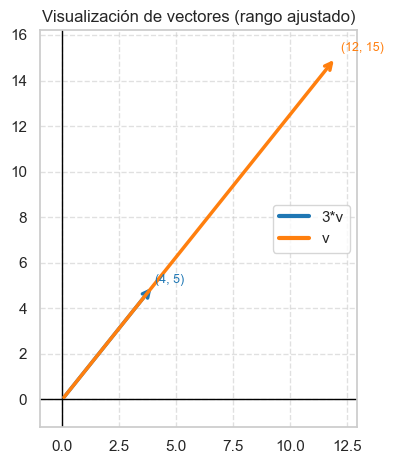

In [30]:
plot_vectors(v,3*v,labels=['3*v','v'])

(<Figure size 640x480 with 1 Axes>, <Axes: >)

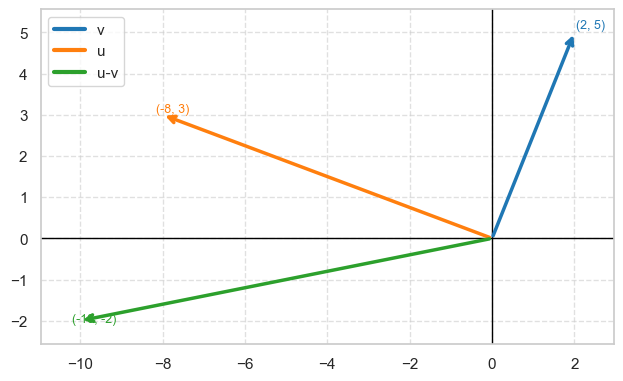

In [33]:
plot_vectors(v,u,u-v,labels=['v','u','u-v'])

> Tip: estas operaciones son **elemento a elemento** (component-wise).

### Operaciones vectorizadas con `NumPy` 
**NumPy** es la base del cómputo numérico en Python: arreglos eficientes, *broadcasting*, y utilidades de álgebra lineal.

In [34]:
# Creación de vectores
a = np.arange(5)          # [0,1,2,3,4]
b = np.linspace(0, 1, 5)  # [0.,0.25,0.5,0.75,1.]
a, b

# Operaciones vectorizadas rápidas
a_plus_b = a + b
three_a  = 3 * a
a_plus_b, three_a

(array([0.  , 1.25, 2.5 , 3.75, 5.  ]), array([ 0,  3,  6,  9, 12]))

### Punto medio de un vector
El **punto medio** entre dos vectores $\vec{u}$ y $\vec{v}$ es:
$$
M = \frac{\vec{u} + \vec{v}}{2}
$$


In [35]:
u = np.array([2, 4])
v = np.array([6, 8])
M = (u + v) / 2
M

array([4., 6.])

(<Figure size 640x480 with 1 Axes>, <Axes: >)

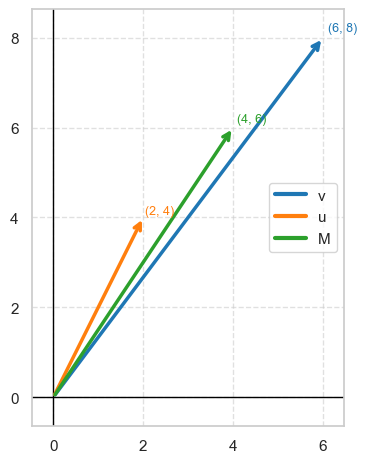

In [36]:
plot_vectors(v,u,M,labels=['v','u','M'])

### Longitud de un vector (norma)
La **norma euclideana** (o longitud) de un vector es:
$$
\|\vec{v}\|_2 = \sqrt{v_1^2 + v_2^2 + \cdots + v_n^2}
$$

Más general, la **norma-$p$**:
$$
\|\vec{v}\|_p = \left(\sum_{i=1}^n |v_i|^p\right)^{1/p}
$$

In [5]:
v = np.array([3, 4])
np.linalg.norm(v)  # 5.0

np.float64(5.0)

(<Figure size 640x480 with 1 Axes>, <Axes: >)

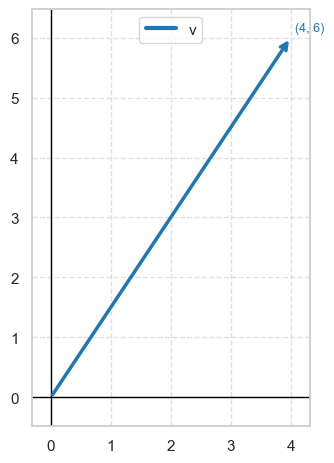

In [38]:
plot_vectors(v,labels=['v'])

### Distancia entre vectores


In [ ]:
u = np.array([1, 1])
v = np.array([4, 3])

(<Figure size 640x480 with 1 Axes>, <Axes: >)

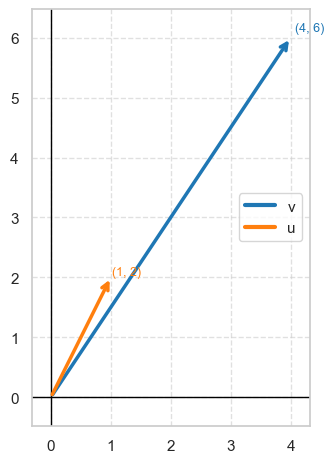

In [40]:
plot_vectors(v,u,labels=['v','u'])

In [ ]:

np.linalg.norm(u - v)

np.float64(5.0)


### Distancia Manhattan y Euclideana
- **Manhattan (L1):** $$d_1(\vec{u}, \vec{v}) = \sum_{i=1}^n |u_i - v_i|$$  

<center>
  <img src="https://miro.medium.com/v2/1*C-muC2cpvq9gHchVsFXwPQ.gif" alt="Distancia Manhattan" style="max-width:50%; height:auto;"  width="25%">
</center>




- **Euclideana (L2):** $$d_2(\vec{u}, \vec{v}) = \sqrt{\sum_{i=1}^n (u_i - v_i)^2}$$

<center>
  <img src="https://miro.medium.com/v2/format:webp/1*i9no_hn3bXY_vbbTim09bQ.gif" alt="Distancia euclideana" style="max-width:50%; height:auto;"  width="25%">
</center>






In [41]:
u = np.array([1, 1])
v = np.array([4, 3])

dist_manhattan = np.sum(np.abs(u - v))
dist_euclid    = np.linalg.norm(u - v)
dist_manhattan, dist_euclid

(np.int64(5), np.float64(3.605551275463989))

> Intuición: L1 “suma cuadras” (como calles en retícula), L2 “línea recta” 📏.


### Algoritmo KNN (K-Nearest Neighbors)
**KNN** clasifica un punto nuevo usando la clase mayoritaria de sus *k vecinos más cercanos* según una métrica de distancia. Es un modelo basado en **similitud**.

Pasos:
1. Calcular distancias del nuevo punto a todos los puntos de entrenamiento.  
2. Elegir los $k$ índices con menor distancia.  
3. Votar la clase más frecuente entre esos $k$ vecinos.





In [42]:
from collections import Counter

# Datos 2D (clases "A" y "B")
X = np.array([[1,2],[2,3],[3,3],[6,6],[7,7],[8,6]])
y = np.array(["A","A","A","B","B","B"])

x_nuevo = np.array([4,4])
k = 3

# Distancias euclideanas a x_nuevo
d = np.linalg.norm(X - x_nuevo, axis=1)

# k vecinos más cercanos
idx = np.argsort(d)[:k]
vecinos = y[idx]

# Votación
pred = Counter(vecinos).most_common(1)[0][0]
vecinos, pred  # (array de vecinos, clase predicha)

(array(['A', 'A', 'B'], dtype='<U1'), np.str_('A'))

> Nota: Puedes cambiar la métrica usando L1 (Manhattan) reemplazando `np.linalg.norm(X - x_nuevo, axis=1)` por `np.sum(np.abs(X - x_nuevo), axis=1)`.

---


## Matrices

### ¿Qué es una matriz?
Una **matriz** es un arreglo rectangular de números. La usamos para representar datos (filas=observaciones, columnas=características) o transformaciones lineales.  
Notación: $A \in \mathbb{R}^{m \times n}$.

$$A=\begin{bmatrix}
a_{11} & a_{12} & \dots & a_{1n}\\
a_{21} & a_{22} & \dots & a_{2n}\\
\vdots & \vdots & \ddots & \vdots\\
a_{m1} & a_{m2} & \dots & a_{mn}
\end{bmatrix}$$

In [43]:
A = np.array([[1, 2, 3],
                [4, 5, 6]])   # 2 filas x 3 columnas
A


array([[1, 2, 3],
       [4, 5, 6]])

### Dimensión de una matriz
La **dimensión** (o *shape*) es $m \times n$: número de filas por número de columnas.

    A.shape   # (2, 3) → 2x3

> Intuición: piensa en una hoja con *m* renglones y *n* columnas.


In [44]:
A.shape   # (2, 3) → 2x3

(2, 3)

### Matriz identidad

La **matriz identidad** $I_n$ es una matriz cuadrada $n\times n$ con unos en la diagonal principal y ceros en el resto. Actúa como el *1* de las matrices: deja todo igual al multiplicar.

$$
I_n=\begin{bmatrix}
1 & 0 & \cdots & 0\\
0 & 1 & \cdots & 0\\
\vdots & \vdots & \ddots & \vdots\\
0 & 0 & \cdots & 1
\end{bmatrix},\qquad
I_n\,x = x,\quad A\,I_n=A,\quad I_m\,A=A
$$


In [51]:
I = np.eye(3)
I


array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]])

### Transpuesta de una matriz
La **transpuesta** intercambia filas por columnas.  
Definición: $(A^\top)_{ij} = A_{ji}$  
Propiedades útiles: $(A^\top)^\top = A$, $(AB)^\top = B^\top A^\top$.

In [46]:
A = np.array([[1, 2, 3],
                [4, 5, 6]])    # 2x3
AT = A.T                     # 3x2
A,A.shape, AT, AT.shape

(array([[1, 2, 3],
        [4, 5, 6]]),
 (2, 3),
 array([[1, 4],
        [2, 5],
        [3, 6]]),
 (3, 2))

### Matriz por un escalar
Multiplicar por un número real $k$ escala todos los elementos:  
$kA = [k\cdot a_{ij}]$

In [47]:
k = 3
kA = k * A
A,kA


(array([[1, 2, 3],
        [4, 5, 6]]),
 array([[ 3,  6,  9],
        [12, 15, 18]]))

### Suma de matrices
Se suman **elemento a elemento** y requieren la misma dimensión:  
$A + B = [\,a_{ij} + b_{ij}\,]$


In [48]:
B = np.array([[10, 10, 10],
                [20, 20, 20]])
A_plus_B = A + B
A,B,A_plus_B


(array([[1, 2, 3],
        [4, 5, 6]]),
 array([[10, 10, 10],
        [20, 20, 20]]),
 array([[11, 12, 13],
        [24, 25, 26]]))

> Si las dimensiones no coinciden, NumPy lanza un error (o intenta *broadcasting*, que en suma de matrices clásicas no aplica si no es compatible).

### Multiplicación de matrices
La multiplicación de matrices compone transformaciones lineales.  
Dimensiones: si $A\in\mathbb{R}^{m\times n}$ y $B\in\mathbb{R}^{n\times p}$, entonces $C=AB\in\mathbb{R}^{m\times p}$.

Elemento $(i,j)$:  
$C_{ij}=\sum_{k=1}^{n} a_{ik}\,b_{kj}$

In [50]:
A = np.array([[1, 2, 3],    # 2x3
                [4, 5, 6]])
B = np.array([[1,  0],      # 3x2
                [0,  1],
                [-1, 2]])

C1 = A @ B          # operador @ (producto matricial)
C2 = np.matmul(A, B)

> Intuición: cada entrada de $C$ es el **producto punto** entre una fila de $A$ y una columna de $B$.

### Inversa de una matriz
La **inversa** $A^{-1}$ existe sólo si $A$ es **cuadrada** y **no singular** (determinante distinto de 0).  
Definición: $A\,A^{-1}=A^{-1}A=I$ (la identidad).


In [ ]:
A = np.array([[4., 7.],
                [2., 6.]])     # det = 4*6 - 7*2 = 10 ≠ 0 (invertible)

detA = np.linalg.det(A)
invA = np.linalg.inv(A)
check_left  = A @ invA
check_right = invA @ A

## El problema de la regresión lineal desde álgebra lineal


Queremos ajustar un modelo lineal que explique un vector de respuestas $y$ a partir de las columnas (características) de una matriz de diseño $X$:
$$
y \approx X\beta \quad\text{con}\quad X\in\mathbb{R}^{n\times p},\; y\in\mathbb{R}^{n},\; \beta\in\mathbb{R}^{p}.
$$



$$
\begin{bmatrix}
y_1\\
y_2\\
\vdots\\
y_n
\end{bmatrix}
=
\begin{bmatrix}
1 & x_{1,1} & \cdots & x_{1,p}\\
1 & x_{2,1} & \cdots & x_{2,p}\\
\vdots & \vdots & \ddots & \vdots\\
1 & x_{n,1} & \cdots & x_{n,p}
\end{bmatrix}
\begin{bmatrix}
\beta_0\\
\beta_1\\
\vdots\\
\beta_p
\end{bmatrix}
$$




### Deduccion por mínimos cuadrados de $SSE$ 


<center>
    <img src="https://bookdown.org/ybrandvain/Applied-Biostats/images/ols.gif" alt="IA para educación - Logo" style="max-width:50%; height:auto;"  width="25%">
</center>



#### *1) Método de Mínimos Cuadrados (objetivo)*

Buscamos el vector de coeficientes $\beta\in\mathbb{R}^{p}$ que minimiza la **suma de cuadrados de errores** (SSE):
$$
\mathrm{SSE}(\beta)=\varepsilon^\top\varepsilon=(y - X\beta)^\top(y - X\beta),
$$
donde $X\in\mathbb{R}^{n\times p}$ es la matriz de diseño, $y\in\mathbb{R}^n$ es el vector de respuestas y $\varepsilon=y-X\beta$ es el residuo.

---

### *2) Derivación de la solución* 

Expandimos $\mathrm{SSE}(\beta)$ usando álgebra matricial:
$$
\begin{aligned}
\mathrm{SSE}(\beta)
&=(y-X\beta)^\top(y-X\beta)\\
&=y^\top y - 2\,y^\top X\beta + \beta^\top X^\top X \beta.
\end{aligned}
$$

Derivamos con respecto a $\beta$ y anulamos el gradiente (igualar a cero):
$$
\nabla_\beta \mathrm{SSE}(\beta)= -2X^\top y + 2X^\top X\,\beta = 0
\;\;\Longrightarrow\;\;
X^\top X\,\beta = X^\top y.
$$



### 3) Solución matricial
Si $X^\top X$ es invertible, la solución única que minimiza SSE es:
$$
\boxed{\;\hat\beta = (X^\top X)^{-1}X^\top y\;}
$$


https://bookdown.org/ybrandvain/Applied-Biostats/images/ols.gif